https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=PSCompPars

Source for Dataset : NASA Exoplanet Archive - Planetary Systems Composite Parameters

In [1]:
import pandas as pd

df = pd.read_csv("NASA Exoplanet dataset.csv", comment='#')
df.head()

,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007,Xinglong Station,0,323.21000,0.06000,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20000,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008,Okayama Astrophysical Observatory,0,186.76000,0.11000,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002,W. M. Keck Observatory,0,1765.03890,1.67709,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996,Multiple Observatories,0,798.50000,1.00000,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603


Planet radius, mass, surface temperature, orbital period, 
distance from star, Host star type, temperature, metallicity are present in the dataset

density, luminosity can be computed

Density = Mass / Volume

In [2]:
import numpy as np

EARTH_DENSITY = 5.51 

df["pl_density"] = (df["pl_bmasse"] / (df["pl_rade"]**3)) * EARTH_DENSITY


df[["pl_name", "pl_density"]].head()

,pl_name,pl_density
0,11 Com b,14.913743
1,11 UMi b,13.871666
2,14 And b,2.772416
3,14 Her b,7.050020
4,16 Cyg B b,1.266967


In [3]:
SUN_TEMP = 5772 
df["st_luminosity"] = (df["st_rad"]**2) * (df["st_teff"] / SUN_TEMP)**4
df[["pl_name", "st_luminosity"]].head()

,pl_name,st_luminosity
0,11 Com b,96.266166
1,11 UMi b,251.884564
2,14 And b,68.609376
3,14 Her b,0.632667
4,16 Cyg B b,1.257543


Schema of dataset

In [4]:
print("ROWS:", df.shape[0])
print("COLUMNS:", df.shape[1])
print("\nCOLUMN TYPES:\n", df.dtypes)
print("\nMISSING VALUES:\n", df.isnull().sum())

ROWS: 6052
COLUMNS: 86

COLUMN TYPES:
 pl_name             object
hostname            object
sy_snum              int64
sy_pnum              int64
discoverymethod     object
                    ...   
sy_gaiamag         float64
sy_gaiamagerr1     float64
sy_gaiamagerr2     float64
pl_density         float64
st_luminosity      float64
Length: 86, dtype: object

MISSING VALUES:
 pl_name              0
hostname             0
sy_snum              0
sy_pnum              0
discoverymethod      0
                  ... 
sy_gaiamag         325
sy_gaiamagerr1     326
sy_gaiamagerr2     326
pl_density          49
st_luminosity      301
Length: 86, dtype: int64


Only the needed columns are extracted.
pl_name (ID column)
hostname (Star system name)
pl_rade → Planet radius
pl_bmasse → Planet mass
pl_density → (Computed density)
pl_eqt → Surface temperature (equilibrium temperature)
pl_orbper → Orbital period
pl_orbsmax → Distance from star (semi-major axis)
st_spectype → Star type
st_teff → Star temperature
st_met → Metallicity
st_luminosity → (Computed luminosity)

In [5]:
needed_columns = [
    "pl_name",
    "hostname",
    "pl_rade",
    "pl_bmasse",
    "pl_density",
    "pl_eqt",
    "pl_orbper",
    "pl_orbsmax",
    "st_spectype",
    "st_teff",
    "st_met",
    "st_luminosity"
]

df_main = df[needed_columns].copy()

df_main.head()


,pl_name,hostname,pl_rade,pl_bmasse,pl_density,pl_eqt,pl_orbper,pl_orbsmax,st_spectype,st_teff,st_met,st_luminosity
0,11 Com b,11 Com,12.2,4914.898486,14.913743,NaN,323.21000,1.178,G8 III,4874.0,-0.2600,96.266166
1,11 UMi b,11 UMi,12.3,4684.814200,13.871666,NaN,516.21997,1.530,K4 III,4213.0,-0.0200,251.884564
2,14 And b,14 And,13.1,1131.151301,2.772416,NaN,186.76000,0.775,K0 III,4888.0,-0.2100,68.609376
3,14 Her b,14 Her,12.6,2559.472162,7.050020,NaN,1765.03890,2.774,K0V,5338.0,0.4052,0.632667
4,16 Cyg B b,16 Cyg B,13.5,565.737400,1.266967,NaN,798.50000,1.660,G3 V,5750.0,0.0600,1.257543


In [6]:
#Handling missing values:
df_main.isnull().sum()

pl_name             0
hostname            0
pl_rade            25
pl_bmasse          31
pl_density         49
pl_eqt           1538
pl_orbper         315
pl_orbsmax        303
st_spectype      3821
st_teff           276
st_met            530
st_luminosity     301
dtype: int64

In [7]:
#Filling the numerical columns using Median
num_cols = ["pl_rade", "pl_bmasse", "pl_eqt", "pl_orbper",
            "pl_orbsmax", "st_teff", "st_met"]

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

df_main.loc[:, num_cols] = imputer.fit_transform(df_main[num_cols])


In [8]:
#Recalculating density 
EARTH_DENSITY = 5.51
df_main["pl_density"] = (df_main["pl_bmasse"] / (df_main["pl_rade"]**3)) * EARTH_DENSITY


In [9]:
#Recalculating Luminosity
SUN_TEMP = 5772
df_main["pl_luminosity"] = (df_main["pl_rade"]**2) * (df_main["st_teff"] / SUN_TEMP)**4


In [10]:
#Filling Spectral Type using Mode -> Since it is categorical
df_main["st_spectype"] = df_main["st_spectype"].fillna(df_main["st_spectype"].mode()[0])


In [11]:
#Outlier removal
Q1 = df_main[num_cols].quantile(0.25)
Q3 = df_main[num_cols].quantile(0.75)
IQR = Q3 - Q1

df_main = df_main[
    ~((df_main[num_cols] < (Q1 - 1.5 * IQR)) | 
      (df_main[num_cols] > (Q3 + 1.5 * IQR))
     ).any(axis=1)
]

In [12]:
#Handling inconsistent entries
df_main = df_main[
    (df_main["pl_rade"] > 0) &
    (df_main["pl_bmasse"] > 0) &
    (df_main["pl_eqt"] > 0) &
    (df_main["st_teff"] > 0) &
    (df_main["pl_orbper"] > 0)
]

In [13]:
#Categorical column -> st_spectype (Star Type)
#Let us perform One Hot Encoding on this column
df_main = pd.get_dummies(df_main, columns=["st_spectype"], prefix="star", drop_first=True)


In [14]:
# Lets check for missing values again
df_main.isna().sum()


pl_name        0
hostname       0
pl_rade        0
pl_bmasse      0
pl_density     0
              ..
star_M3.0      0
star_M3.0 V    0
star_M4        0
star_M4 V      0
star_M5.0 V    0
Length: 159, dtype: int64

In [15]:
#HABITABILITY SCORE INDEX
from sklearn.preprocessing import MinMaxScaler

habitability_features = [
    "pl_rade",
    "pl_density",
    "pl_eqt",
    "pl_orbsmax"
]

scaler = MinMaxScaler()

df_main[habitability_features] = scaler.fit_transform(
    df_main[habitability_features]
)

df_main["habitability_score"] = (
    0.30 * (1 - abs(df_main["pl_rade"] - 0.5)) +
    0.30 * (1 - abs(df_main["pl_density"] - 0.5)) +
    0.25 * (1 - abs(df_main["pl_eqt"] - 0.5)) +
    0.15 * (1 - abs(df_main["pl_orbsmax"] - 0.5))
)


In [16]:
#STELLAR COMPATABILITY INDEX
stellar_features = ["st_teff", "st_met", "st_luminosity"]

df_main[stellar_features] = scaler.fit_transform(
    df_main[stellar_features]
)

df_main["stellar_compatibility_index"] = (
    0.4 * (1 - abs(df_main["st_teff"] - 0.5)) +
    0.3 * df_main["st_met"] +
    0.3 * (1 - abs(df_main["st_luminosity"] - 0.5))
)


In [17]:
df_main = df_main.dropna(
    subset=[
        'st_luminosity',
        'stellar_compatibility_index'
    ]
)
df_main[['st_luminosity', 'stellar_compatibility_index']].isna().sum()


st_luminosity                  0
stellar_compatibility_index    0
dtype: int64

In [18]:
#Normalizing numerical features
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

exclude_cols = ["pl_name", "hostname"]
num_cols_final = df_main.select_dtypes(include=["float64", "int64"]).columns

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [19]:
#Data Quality Validation

In [20]:
df_main.describe()


,pl_rade,pl_bmasse,pl_density,pl_eqt,pl_orbper,pl_orbsmax,st_teff,st_met,st_luminosity,pl_luminosity,habitability_score,stellar_compatibility_index
count,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000
mean,0.138378,28.931163,0.001651,0.458881,15.272784,0.175739,0.517768,0.492530,0.050307,22.252327,0.644721,0.649960
std,0.149306,67.550915,0.017768,0.213531,15.626929,0.121487,0.192547,0.190982,0.055754,54.024342,0.045723,0.081346
min,0.001379,0.036400,0.000000,0.000000,0.179719,0.002391,0.000000,0.000000,0.000000,0.063244,0.513852,0.355605
25%,0.056119,3.460000,0.000502,0.299849,4.612362,0.086253,0.416432,0.384921,0.016730,1.777166,0.617969,0.606596
50%,0.087434,6.460000,0.000805,0.440332,9.463352,0.147370,0.565389,0.490741,0.035349,4.337512,0.643795,0.656429
75%,0.126375,12.275000,0.001334,0.589124,19.544303,0.220756,0.653326,0.609788,0.066586,9.991333,0.665100,0.699277
max,1.000000,436.696231,1.000000,1.000000,82.304003,0.689447,1.000000,1.000000,1.000000,568.813732,0.820209,0.879497


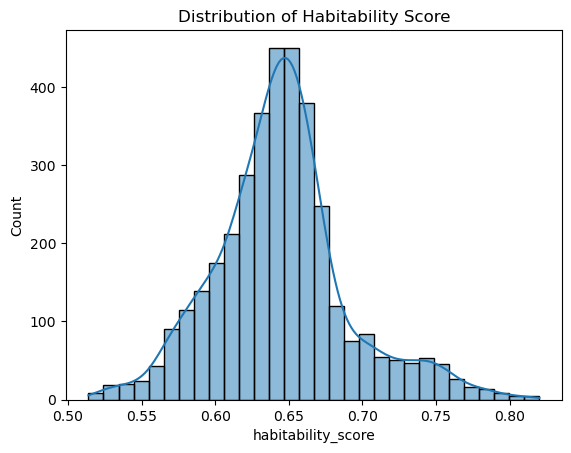

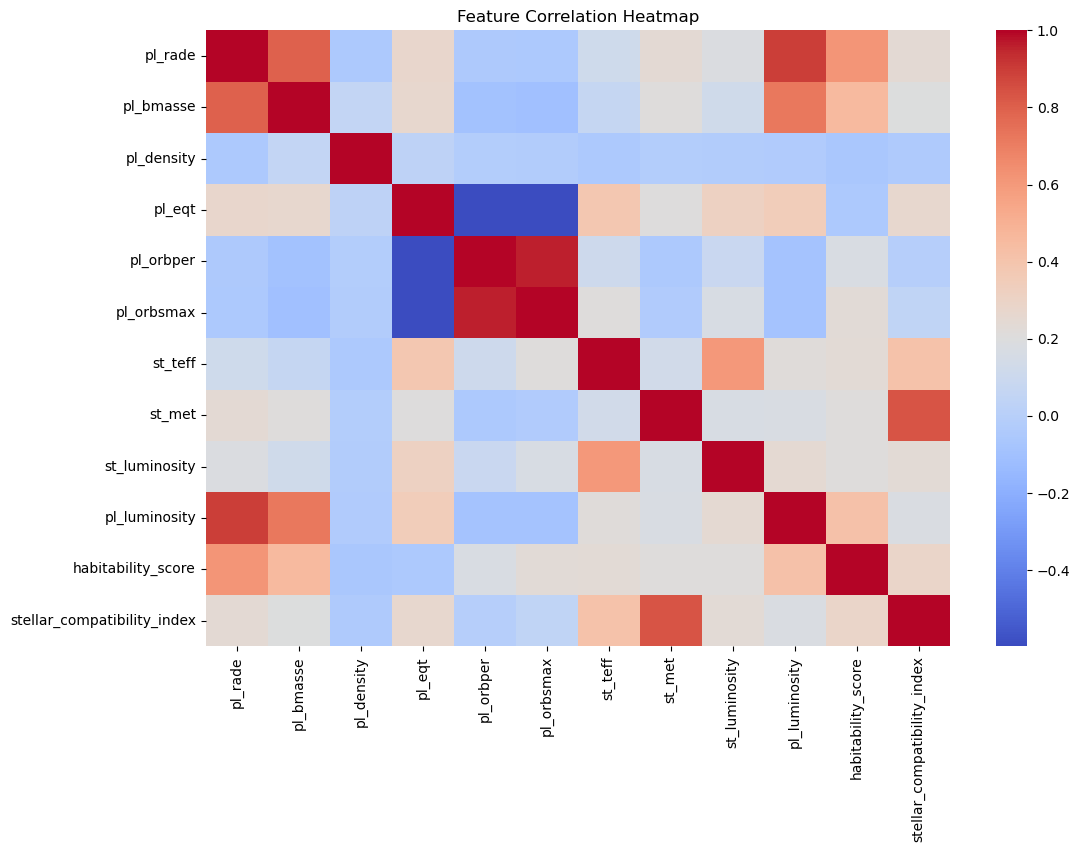

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Habitability Score
sns.histplot(df_main["habitability_score"], bins=30, kde=True)
plt.title("Distribution of Habitability Score")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    df_main[num_cols_final].corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Feature Correlation Heatmap")
plt.show()


In [22]:
# Define threshold (top 25% most habitable planets)
threshold = df_main["habitability_score"].quantile(0.75)

df_main["habitability_class"] = (df_main["habitability_score"] >= threshold).astype(int)


In [23]:
#Computing correlation
corr = df_main.select_dtypes(include=["int64", "float64"]) \
              .corr()["habitability_score"] \
              .abs() \
              .sort_values(ascending=False)

corr

habitability_score             1.000000
pl_rade                        0.613846
pl_bmasse                      0.451360
pl_luminosity                  0.419203
stellar_compatibility_index    0.282557
st_teff                        0.237554
pl_orbsmax                     0.232306
st_met                         0.207982
st_luminosity                  0.207696
pl_orbper                      0.172059
pl_density                     0.061608
pl_eqt                         0.052585
Name: habitability_score, dtype: float64

In [24]:
import numpy as np

numeric_cols = df_main.select_dtypes(include=np.number).columns

corr = df_main[numeric_cols].corr()["habitability_score"].abs()

selected_features = corr[corr > 0.2].index.tolist()

selected_features = [
    col for col in selected_features
    if col not in ["habitability_score", "habitability_class"]
]

selected_features


['pl_rade',
 'pl_bmasse',
 'pl_orbsmax',
 'st_teff',
 'st_met',
 'st_luminosity',
 'pl_luminosity',
 'stellar_compatibility_index']

In [25]:
#Preparing X (Independent) and y (Dependent)
X = df_main[selected_features]
y = df_main["habitability_class"]


In [26]:
#Train - Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
#Creating ML Pipeline 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [28]:
X_train.isna().sum()


pl_rade                        0
pl_bmasse                      0
pl_orbsmax                     0
st_teff                        0
st_met                         0
st_luminosity                  0
pl_luminosity                  0
stellar_compatibility_index    0
dtype: int64

In [29]:
#Model training
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8402203856749312

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89       544
           1       0.67      0.71      0.69       182

    accuracy                           0.84       726
   macro avg       0.79      0.80      0.79       726
weighted avg       0.84      0.84      0.84       726


Confusion Matrix:
 [[480  64]
 [ 52 130]]


In [31]:
#Checking overfitting
train_acc = pipeline.score(X_train, y_train)
test_acc = pipeline.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Train Accuracy: 0.8378099173553719
Test Accuracy: 0.8402203856749312


In [32]:
#Random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

rf_pipeline = Pipeline([
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))

print("\nTrain Accuracy:", rf_pipeline.score(X_train, y_train))
print("Test Accuracy:", rf_pipeline.score(X_test, y_test))

importances = rf_pipeline.named_steps["classifier"].feature_importances_
pd.DataFrame({
    "Feature": selected_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)



Random Forest Accuracy: 0.8691460055096418

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91       544
           1       0.76      0.69      0.73       182

    accuracy                           0.87       726
   macro avg       0.83      0.81      0.82       726
weighted avg       0.87      0.87      0.87       726


Confusion Matrix:
 [[505  39]
 [ 56 126]]

Train Accuracy: 0.9879476584022039
Test Accuracy: 0.8691460055096418


,Feature,Importance
6,pl_luminosity,0.262396
0,pl_rade,0.235012
1,pl_bmasse,0.174509
2,pl_orbsmax,0.102891
5,st_luminosity,0.083071
3,st_teff,0.057943
7,stellar_compatibility_index,0.043152
4,st_met,0.041025


In [33]:
#Overfitting is shown
#Let us reduce overfitting
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df_main[['pl_rade', 'pl_bmasse', 'pl_orbsmax', 
             'st_teff', 'st_met', 'st_luminosity', 
             'pl_luminosity', 'stellar_compatibility_index']]
y = df_main['habitability_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ))
])

# Cross-validation
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
print("CV Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


CV Accuracy Scores: [0.90017212 0.86746988 0.87607573 0.85714286 0.87241379]
Mean CV Accuracy: 0.8746548756602767
Test Accuracy: 0.8829201101928374
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92       544
           1       0.75      0.80      0.77       182

    accuracy                           0.88       726
   macro avg       0.84      0.85      0.85       726
weighted avg       0.89      0.88      0.88       726

Confusion Matrix:
 [[496  48]
 [ 37 145]]


In [34]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [37]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

X = df_main[['pl_rade', 'pl_bmasse', 'pl_orbsmax',
             'st_teff', 'st_met', 'st_luminosity', 'pl_luminosity']]

y = df_main['habitability_class']

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_classes = len(np.unique(y))

xgb_multi = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss'
)

xgb_multi.fit(X_train, y_train)

y_pred = xgb_multi.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

df_main['predicted_habitability_class'] = xgb_multi.predict(X)
df_main['predicted_habitability_score'] = xgb_multi.predict_proba(X).max(axis=1)

df_main.sort_values(
    by='predicted_habitability_score',
    ascending=False
)[['pl_name', 'predicted_habitability_class', 'predicted_habitability_score']].head(10)


Test Accuracy: 0.8801652892561983
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92       544
           1       0.82      0.66      0.74       182

    accuracy                           0.88       726
   macro avg       0.86      0.81      0.83       726
weighted avg       0.88      0.88      0.88       726

Confusion Matrix:
 [[518  26]
 [ 61 121]]


,pl_name,predicted_habitability_class,predicted_habitability_score
2371,Kepler-1197 b,0,0.999997
4601,Kepler-808 b,0,0.999996
2555,Kepler-1331 b,0,0.999995
2171,Kepler-1053 b,0,0.999995
3765,Kepler-304 e,0,0.999995
3755,Kepler-301 b,0,0.999995
2529,Kepler-1315 b,0,0.999995
2320,Kepler-1157 b,0,0.999995
2708,Kepler-1446 b,0,0.999995
2203,Kepler-1073 d,0,0.999995


ROC-AUC Score: 0.9359748707175177


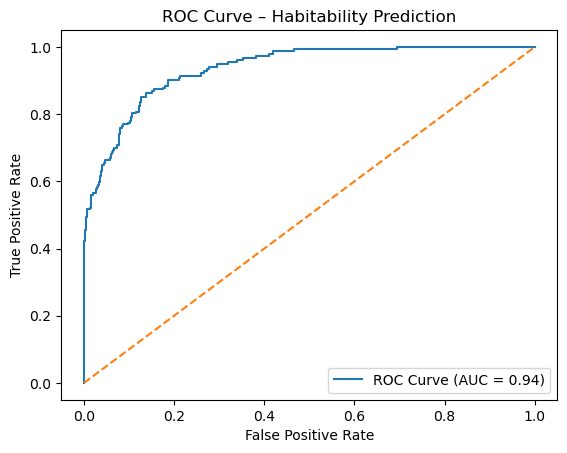

In [39]:
#ROC–AUC (Binary Habitability)
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob = xgb_multi.predict_proba(X_test)[:, 1]

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Habitability Prediction")
plt.legend()
plt.show()
